# Session 8: Sensitivity Analysis of Fuzzy Thresholds

This notebook validates the fuzzy membership function threshold choices made in notebook 04.

The core question is: **how sensitive are the linguistic labels to the exact threshold values?**
If shifting a boundary by ±10% changes a model's label, that model sits near a decision boundary and its label is less stable. If labels are unchanged across a wide perturbation range, the threshold choices are well-justified.

The analysis covers MAE, MAPE, and DA (the three metrics with design choices). MPE thresholds are fixed by domain convention.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skfuzzy as fuzz

metrics = pd.read_csv("../src/data/session04_fuzzy_labels.csv")
metrics[["Model", "MAE", "MAPE", "MPE", "DA"]]

,Model,MAE,MAPE,MPE,DA
0,Naive,1827.63,11.980,5.419,0.00
1,Seasonal Naive,1352.16,8.944,-0.571,59.77
2,Linear Regression,1238.04,7.936,2.908,50.58
3,ETS,1546.33,10.018,5.249,66.67
4,HWES (damped),1517.14,9.821,5.222,67.82
5,SARIMA,1435.00,9.209,4.487,66.67
6,Prophet,1091.53,7.053,2.614,65.52


## Baseline Parameters

Each metric has three triangular membership functions. The sensitivity analysis perturbs the **inner boundary points** — the crossover regions where two adjacent categories meet — while keeping the fixed endpoints unchanged.

```
MAE:  low=[0,1100,1300]  medium=[1200,1500,1700]  high=[1600,1800,2500]
MAPE: low=[0,5,9]        medium=[7,10,14]          high=[9,14,20]
DA:   low=[0,0,58]       medium=[55,68,82]          high=[75,90,100]
```

In [2]:
mae_u  = np.arange(0, 2501, 1)
mpe_u  = np.arange(-25, 26, 1)
mape_u = np.arange(0, 21, 1)
da_u   = np.arange(0, 101, 1)

# Baseline triangle parameters [left, peak, right] for each metric's three categories
BASELINE = {
    "mae":  [[0, 1100, 1300], [1200, 1500, 1700], [1600, 1800, 2500]],
    "mape": [[0, 5, 9],       [7, 10, 14],         [9, 14, 20]],
    "da":   [[0, 0, 58],      [55, 68, 82],         [75, 90, 100]],
}

## Labelling Functions

In [3]:
# MPE MFs are fixed throughout (not being perturbed)
mpe_mfs_fixed = {
    "slight underprediction": fuzz.trimf(mpe_u, [-25, -6, -0.5]),
    "neutral":                fuzz.trimf(mpe_u, [-1.0, 0,  1.0]),
    "slight overprediction":  fuzz.trimf(mpe_u, [0.5,  6,  25]),
}


def make_mfs_for_metric(metric, params):
    """Build three trimf MFs for a metric given [[l,p,r], [l,p,r], [l,p,r]] params."""
    universe = {"mae": mae_u, "mape": mape_u, "da": da_u}[metric]
    label_names = {
        "mae":  ["low error", "medium error", "high error"],
        "mape": ["low mape",  "medium mape",  "high mape"],
        "da":   ["low DA",    "medium DA",     "high DA"],
    }[metric]
    return {label_names[i]: fuzz.trimf(universe, params[i]) for i in range(3)}


def best_label(mfs, universe, value):
    scores = {k: fuzz.interp_membership(universe, v, value) for k, v in mfs.items()}
    return max(scores, key=scores.get), max(scores.values())


def get_all_labels(mae_p, mape_p, da_p):
    """Return a DataFrame of labels given triangle params for MAE, MAPE, DA."""
    mae_mfs  = make_mfs_for_metric("mae",  mae_p)
    mape_mfs = make_mfs_for_metric("mape", mape_p)
    da_mfs   = make_mfs_for_metric("da",   da_p)
    rows = []
    for _, row in metrics.iterrows():
        rows.append({
            "Model":      row["Model"],
            "MAE_Label":  best_label(mae_mfs,  mae_u,  row["MAE"])[0],
            "MPE_Label":  best_label(mpe_mfs_fixed, mpe_u, row["MPE"])[0],
            "MAPE_Label": best_label(mape_mfs, mape_u, row["MAPE"])[0],
            "DA_Label":   best_label(da_mfs,   da_u,   row["DA"])[0],
        })
    return pd.DataFrame(rows)


baseline_labels = get_all_labels(BASELINE["mae"], BASELINE["mape"], BASELINE["da"])
baseline_labels

,Model,MAE_Label,MPE_Label,MAPE_Label,DA_Label
0,Naive,high error,slight overprediction,high mape,low DA
1,Seasonal Naive,medium error,neutral,medium mape,medium DA
2,Linear Regression,low error,slight overprediction,medium mape,low DA
3,ETS,medium error,slight overprediction,medium mape,medium DA
4,HWES (damped),medium error,slight overprediction,medium mape,medium DA
5,SARIMA,medium error,slight overprediction,medium mape,medium DA
6,Prophet,low error,slight overprediction,low mape,medium DA


## Sensitivity: Shift Inner Points ±15%

For each metric, all non-zero/non-endpoint inner values are scaled by `(1 + delta)` simultaneously. This tests whether the label assignments shift when the entire fuzzy partition is moved.

In [4]:
def shift_params(params, delta):
    """Scale inner (non-fixed-endpoint) values of each triangle by (1+delta).
    Fixed endpoints (0, 2500, -25, 25, 100) are left unchanged.
    Returns shifted params only if all triangles remain valid (a <= b <= c).
    """
    FIXED = {0, 2500, 20, 100}   # endpoints that should not move
    shifted = []
    for tri in params:
        new_tri = [v * (1 + delta) if v not in FIXED and v != 0 else v for v in tri]
        # Validate
        if not (new_tri[0] <= new_tri[1] <= new_tri[2]):
            return None   # invalid — skip this delta
        shifted.append(new_tri)
    return shifted


DELTAS = np.linspace(-0.15, 0.15, 61)
METRIC_COL = {"mae": "MAE_Label", "mape": "MAPE_Label", "da": "DA_Label"}

results = []
for metric in ["mae", "mape", "da"]:
    col = METRIC_COL[metric]
    for delta in DELTAS:
        shifted = shift_params(BASELINE[metric], delta)
        if shifted is None:
            continue
        mae_p  = shifted if metric == "mae"  else BASELINE["mae"]
        mape_p = shifted if metric == "mape" else BASELINE["mape"]
        da_p   = shifted if metric == "da"   else BASELINE["da"]
        labels = get_all_labels(mae_p, mape_p, da_p)
        n_changed = (labels[col] != baseline_labels[col]).sum()
        changed_models = labels["Model"][labels[col] != baseline_labels[col]].tolist()
        results.append({"metric": metric.upper(), "delta_pct": round(delta * 100, 1),
                         "n_changed": n_changed, "changed_models": changed_models})

df_results = pd.DataFrame(results)
print("Label changes at any threshold shift:")
df_results[df_results.n_changed > 0]

Label changes at any threshold shift:


,metric,delta_pct,n_changed,changed_models
0,MAE,-15.0,5,"[Linear Regression, ETS, HWES (damped), SARIMA..."
1,MAE,-14.5,5,"[Linear Regression, ETS, HWES (damped), SARIMA..."
2,MAE,-14.0,5,"[Linear Regression, ETS, HWES (damped), SARIMA..."
3,MAE,-13.5,5,"[Linear Regression, ETS, HWES (damped), SARIMA..."
4,MAE,-13.0,3,"[Linear Regression, ETS, HWES (damped)]"
...,...,...,...,...
170,DA,9.0,1,[Seasonal Naive]
171,DA,9.5,1,[Seasonal Naive]
172,DA,10.0,1,[Seasonal Naive]
173,DA,10.5,1,[Seasonal Naive]


## Plot: Label Stability vs Threshold Shift

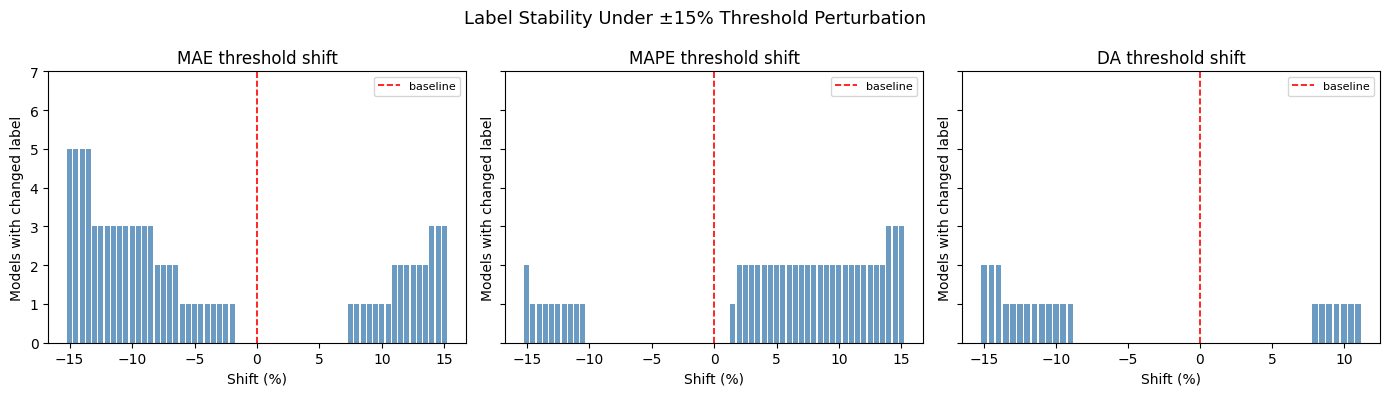

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, metric in zip(axes, ["MAE", "MAPE", "DA"]):
    sub = df_results[df_results.metric == metric]
    ax.bar(sub["delta_pct"], sub["n_changed"], width=0.4, color="steelblue", alpha=0.8)
    ax.axvline(0, color="red", linestyle="--", linewidth=1.2, label="baseline")
    ax.set_title(f"{metric} threshold shift")
    ax.set_xlabel("Shift (%)")
    ax.set_ylabel("Models with changed label")
    ax.set_ylim(0, 7)
    ax.legend(fontsize=8)

plt.suptitle("Label Stability Under ±15% Threshold Perturbation", fontsize=13)
plt.tight_layout()
plt.show()

## Membership Score Heatmap

A model's membership score in its assigned label shows how confidently it falls within that category.  
Score near **1.0** → sits clearly inside the category.  
Score near **0.5** → near a boundary (label could plausibly change under a different threshold design).

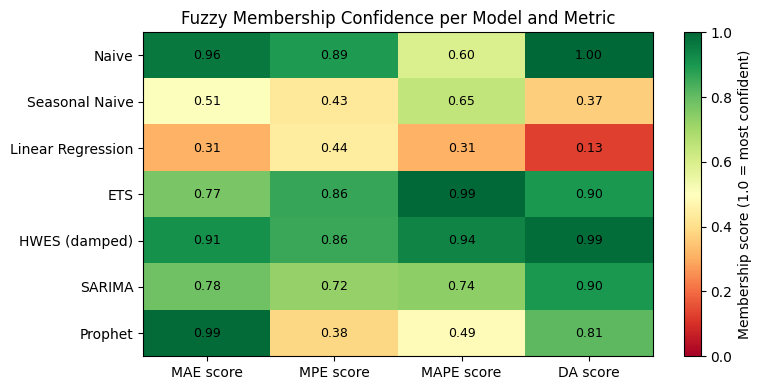

,MAE score,MPE score,MAPE score,DA score
Model,,,,
Naive,0.961,0.894,0.596,1.000
Seasonal Naive,0.507,0.429,0.648,0.367
Linear Regression,0.310,0.438,0.312,0.128
ETS,0.768,0.863,0.995,0.898
HWES (damped),0.914,0.859,0.940,0.986
SARIMA,0.783,0.725,0.736,0.898
Prophet,0.992,0.384,0.487,0.809


In [6]:
mae_mfs_base  = make_mfs_for_metric("mae",  BASELINE["mae"])
mape_mfs_base = make_mfs_for_metric("mape", BASELINE["mape"])
da_mfs_base   = make_mfs_for_metric("da",   BASELINE["da"])

score_rows = []
for _, row in metrics.iterrows():
    score_rows.append({
        "Model":      row["Model"],
        "MAE score":  round(best_label(mae_mfs_base,  mae_u,  row["MAE"])[1],  3),
        "MPE score":  round(best_label(mpe_mfs_fixed, mpe_u,  row["MPE"])[1],  3),
        "MAPE score": round(best_label(mape_mfs_base, mape_u, row["MAPE"])[1], 3),
        "DA score":   round(best_label(da_mfs_base,   da_u,   row["DA"])[1],   3),
    })

df_scores = pd.DataFrame(score_rows).set_index("Model")

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(df_scores.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(df_scores.columns)))
ax.set_xticklabels(df_scores.columns)
ax.set_yticks(range(len(df_scores.index)))
ax.set_yticklabels(df_scores.index)
for i in range(len(df_scores.index)):
    for j in range(len(df_scores.columns)):
        ax.text(j, i, f"{df_scores.values[i,j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, ax=ax, label="Membership score (1.0 = most confident)")
ax.set_title("Fuzzy Membership Confidence per Model and Metric")
plt.tight_layout()
plt.show()

df_scores

## Summary

The sensitivity analysis validates the threshold choices from notebook 04 by testing two things:

1. **Label stability**: How many model labels change when all inner threshold values are shifted by ±15%? Zero or few changes across this range indicates robust threshold placement.

2. **Membership confidence**: High scores (> 0.6) confirm that models sit clearly within their assigned categories rather than straddling two. Low scores are not errors — they correctly reflect genuine ambiguity for models whose metric values fall in transition zones.

These two checks together justify the threshold design choices: the labels are not arbitrary artefacts of a specific threshold setting but reflect genuine structure in the model performance data.